# Single Variable Effect (Fixed Controls)

此 notebook 提供兩種繪圖方式：
1. 多線段合併在同一張圖（每條線是控制組）。
2. 多圖輸出（每個控制組一張小圖）。

使用前先設定 `variable`、`metrics`、`controls`。


In [75]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

ANALYZE_DIR = Path('../outputFiles/analyze').resolve()
REPORT_PREFIX = os.environ.get('REPORT_PREFIX', 'analysis_reports')
COLLECT_PREFIX = os.environ.get('COLLECT_PREFIX', REPORT_PREFIX)
COLLECT_DIR = (ANALYZE_DIR / COLLECT_PREFIX).resolve()

COLLECT_CSV = '../outputFiles/analyze/sift01/collected_all_sift01_20260116_224916.csv'  # 可手動指定 collected_all_*.csv

def pick_latest(pattern):
    files = list(COLLECT_DIR.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files matched: {pattern} in {COLLECT_DIR}')
    return max(files, key=lambda p: p.stat().st_mtime)

stats_path = Path(COLLECT_CSV) if COLLECT_CSV else pick_latest('collected_all_*.csv')
print('stats:', stats_path)
df = pd.read_csv(stats_path)
df.head(3)


stats: ../outputFiles/analyze/sift01/collected_all_sift01_20260116_224916.csv


,id,dataset_name,data_type,build_R,build_L,build_B,build_M,search_K,search_L,search_W,...,topk_expanded_degree_p1,topk_expanded_degree_p5,topk_expanded_degree_p10,topk_expanded_degree_p25,topk_expanded_degree_p50,topk_expanded_degree_p75,topk_expanded_degree_p90,topk_expanded_degree_p95,topk_expanded_degree_p99,topk_expanded_degree_p100
0,1,sift,float,128,256,2.0,2.0,10,10,2,...,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0
1,2,sift,float,128,256,2.0,2.0,10,10,2,...,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0
2,3,sift,float,128,256,2.0,2.0,10,10,2,...,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0,128.0


In [ ]:
# === variable 可為多欄位組合 ===

def plot_effect_auto(df, variables, metrics, controls, min_unique=3, max_groups=6,
                     label_rotation=45, label_max_len=24):
    """
    variables 可為單一欄位或多欄位組合。
    - variables: 字串或欄位清單，例如 ['build_R','build_L']
    - controls: 其他要固定的變量清單
    - label_rotation: x 軸標籤旋轉角度
    - label_max_len: 組合標籤最大長度（超過會截斷）

    當 variables 有多欄位時：
    - 2 個欄位：x=variables[0], hue=variables[1]
    - >=3 個欄位：合併成一個 categorical x 軸（用字串組合）
    """
    if isinstance(variables, str):
        variables = [variables]
    if not variables or not all(isinstance(v, str) for v in variables):
        raise ValueError('variables 必須是欄位名稱字串或字串清單')

    def select_control_groups_local(df, variables, controls, min_unique=3, max_groups=6):
        grouped = df.groupby(controls, dropna=False)
        candidates = []
        for key, sub in grouped:
            uniq = sub[variables].drop_duplicates().shape[0]
            if uniq >= min_unique:
                candidates.append((uniq, key, sub))
        candidates.sort(key=lambda x: x[0], reverse=True)
        return candidates[:max_groups]

    def format_key(controls, key):
        key_tuple = key if isinstance(key, tuple) else (key,)
        return ', '.join([f'{c}={v}' for c, v in zip(controls, key_tuple)])

    def format_combo_label(row, variables):
        parts = [f"{v}={row[v]}" for v in variables]
        label = '_'.join(parts)
        if label_max_len and len(label) > label_max_len:
            return label[: label_max_len - 1] + '…'
        return label

    groups = select_control_groups_local(df, variables, controls, min_unique=min_unique, max_groups=max_groups)
    if not groups:
        print(f"沒有找到 {variables} 有至少 {min_unique} 種組合的控制組。")
        return

    for uniq, key, sub in groups:
        sub = sub.copy()
        for v in variables:
            sub[v] = pd.to_numeric(sub[v], errors='ignore')

        if len(variables) == 1:
            x_var = variables[0]
            hue_var = None
            x_col = x_var
        elif len(variables) == 2:
            x_var, hue_var = variables
            x_col = x_var
        else:
            x_var, hue_var = variables[0], None
            x_col = '_'.join(variables)
            sub[x_col] = sub.apply(lambda r: format_combo_label(r, variables), axis=1)

        sub = sub.sort_values(by=x_col)

        n = len(metrics)
        cols = min(3, n)
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols + 3, 3.2 * rows + 1), squeeze=False)
        fig.suptitle(f'{variables} Effect | {format_key(controls, key)} | unique={uniq}', fontsize=12)

        for i, metric in enumerate(metrics):
            ax = axes[i // cols][i % cols]
            if metric not in sub.columns:
                ax.set_title(f'{metric} not found')
                ax.axis('off')
                continue
            if hue_var:
                sns.lineplot(ax=ax, data=sub, x=x_col, y=metric, hue=hue_var, marker='o')
                ax.legend(fontsize=8)
            else:
                sns.lineplot(ax=ax, data=sub, x=x_col, y=metric, marker='o')
            ax.set_xlabel(x_col)
            ax.set_ylabel(metric)
            ax.tick_params(axis='x', labelrotation=label_rotation)
            ax.grid(True, alpha=0.3)

        for j in range(n, rows * cols):
            axes[j // cols][j % cols].axis('off')

        plt.tight_layout()
        plt.show()


In [ ]:
# 設定分析變量
# variable: 想看影響的變量（例如 build_R）
# metrics: 想觀察的指標（可多個）
# controls: 其他要固定的變量

CONTROL_VARS_ALL = [
    'build_R','build_L',
    'search_K','search_L','search_W','search_T',
    'actual_cached_nodes',
]

variable = ['search_L','search_W','actual_cached_nodes']
metrics = ['latency_us_p99', 'qps']
controls = [c for c in CONTROL_VARS_ALL if c not in variable]

/tmp/ipykernel_695574/675931767.py:53: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sub[v] = pd.to_numeric(sub[v], errors='ignore')


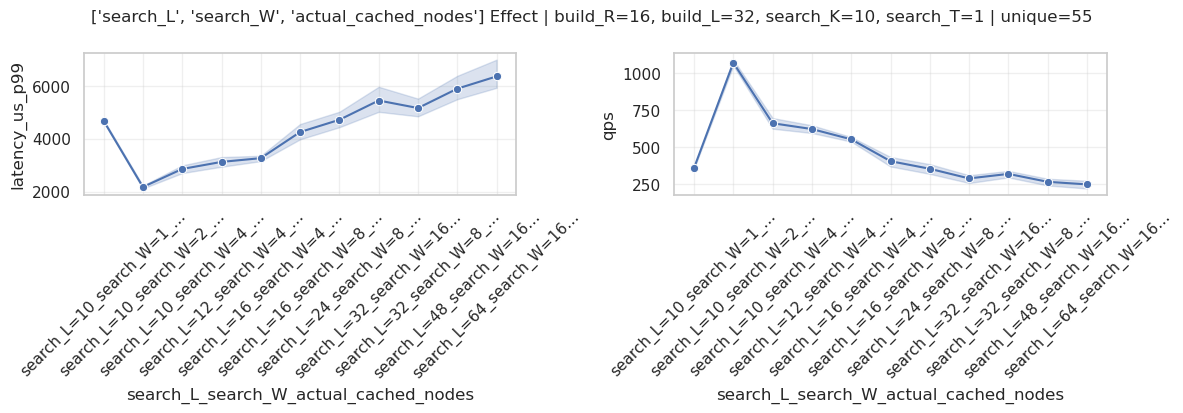

/tmp/ipykernel_695574/675931767.py:53: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sub[v] = pd.to_numeric(sub[v], errors='ignore')


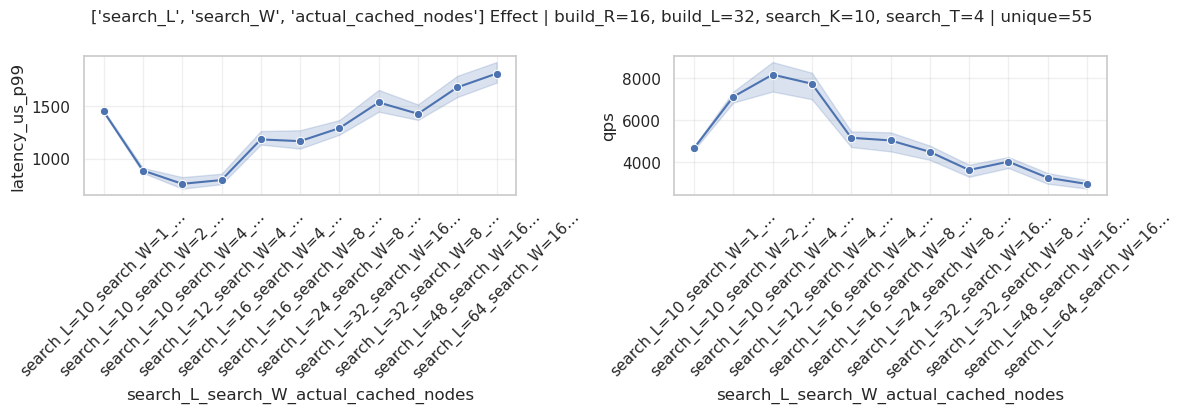

/tmp/ipykernel_695574/675931767.py:53: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sub[v] = pd.to_numeric(sub[v], errors='ignore')


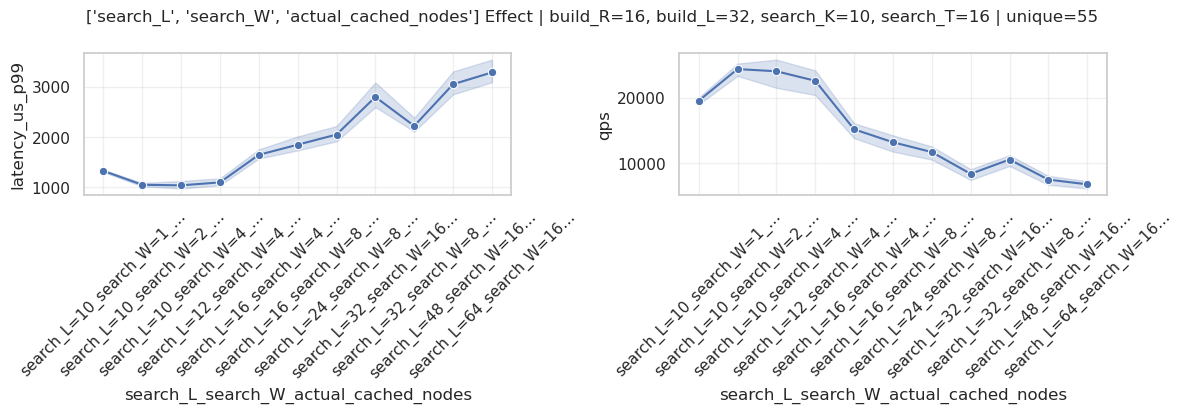

/tmp/ipykernel_695574/675931767.py:53: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sub[v] = pd.to_numeric(sub[v], errors='ignore')


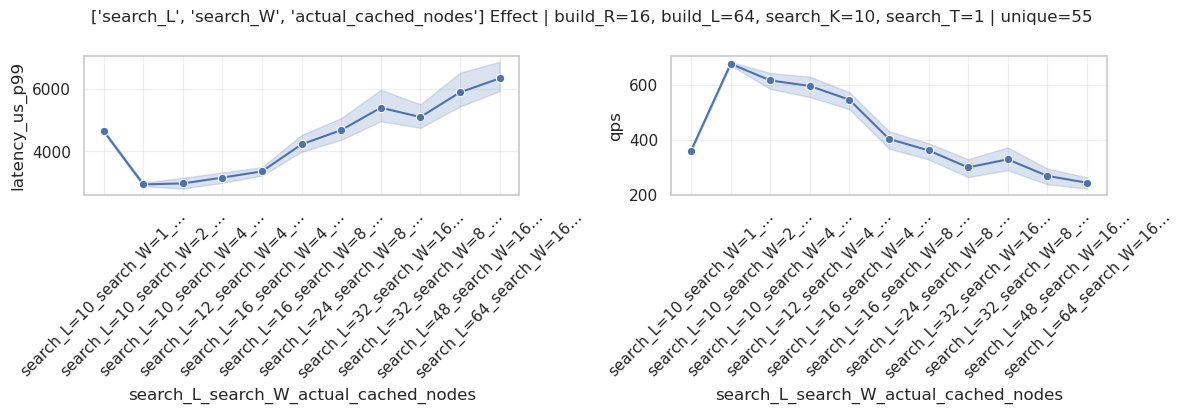

/tmp/ipykernel_695574/675931767.py:53: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sub[v] = pd.to_numeric(sub[v], errors='ignore')


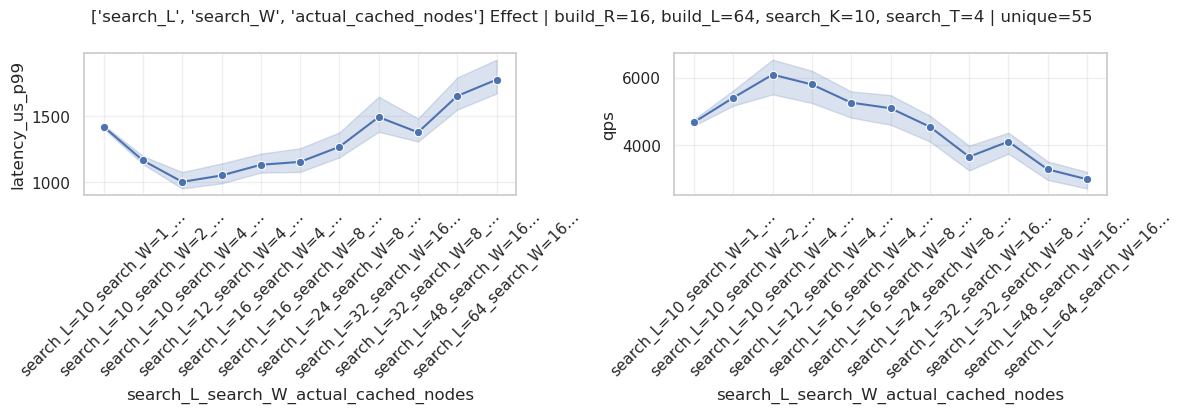

/tmp/ipykernel_695574/675931767.py:53: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  sub[v] = pd.to_numeric(sub[v], errors='ignore')


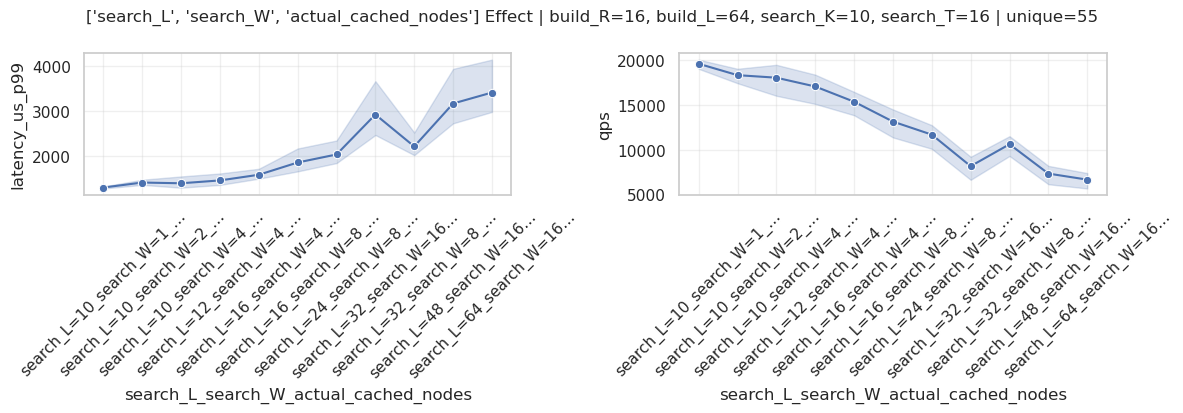

In [ ]:
# 統一入口示例
# variable=['build_R'] -> 單變量
# variable=['build_R','build_L'] -> 兩變量（hue）
# variable=['build_R','build_L','search_W'] -> 多變量組合
plot_effect_auto(df, variable, metrics, controls, min_unique=3, max_groups=6)
